# Итоговое решение: обнаружение автоматизированного трафика
## Василенко Егор, egor.vasilenko.2004@mail.ru | Отбор на Avito DS Bootcamp

## Постановка задачи

По событиям внутри суточного окна необходимо предсказать для каждой `cookie_id` оценку принадлежности к трафику известных сервисов автоматизированного сбора данных.

Целевая переменная:
- `1` — трафик известных сервисов сбора данных;
- `0` — трафик, отнесённый к человеческому.

Основная метрика — максимальный Precision среди порогов, обеспечивающих Recall не ниже 70%.

Признаки рассчитываются только по событиям внутри окна: `window_start_ts ≤ event_ts < window_end_ts`. Для локальной оценки используется временное разбиение, поскольку тест расположен позже обучения.

Результат — файл `submission.csv` с колонками `cookie_id` и `score`.

## Подход к решению

Для каждой куки собираем признаки по событиям внутри её суточного окна. В итоговом варианте используются 337 признаков: 189 поведенческих и временных признаков и 148 долей конкретных User-Agent.

Модель — ансамбль трёх LightGBM. Они отличаются долей признаков, используемых при построении деревьев, и минимальным числом наблюдений в листе. Оценки моделей усредняются с равными весами.

Качество проверяем на трёх последовательных временных периодах. После валидации обучаем модели на всей размеченной выборке и формируем submission.csv.

Подробный ход исследования и код остальных экспериментов сохранены в research.ipynb.

## Что проверялось

Начал с простых моделей и постепенно расширял набор признаков. В таблице приведены результаты на одном периоде валидации: 13–16 апреля 2026 года. Обучение выполнялось на данных до 13 апреля.

| Вариант | P@R≥0.7 |
|---|---:|
| Константный baseline | 0.0773 |
| RandomForest на двух признаках активности | 0.1000 |
| LogisticRegression на 23 базовых признаках | 0.1993 |
| CatBoost на 23 базовых признаках | 0.1951 |
| CatBoost с добавлением временных признаков | 0.3107 |
| CatBoost с добавлением разнообразия просмотров и поиска | 0.3937 |
| CatBoost с расширенными временными признаками | 0.4183 |
| LightGBM на расширенном наборе из 189 признаков | 0.6932 |
| Итоговый ансамбль LightGBM на 337 признаках | 0.7373 |

Таблица сравнивает варианты решения целиком. В ходе исследования менялись и признаки, и параметры моделей, поэтому весь прирост нельзя приписать одной группе признаков.

Дополнительно проверялись:
- Обобщённые признаки User-Agent: браузер, операционная система и маркеры автоматизации. На первоначальном наборе они не улучшили основную метрику.
- Повторяемость позиций курсора. Первоначальный вариант не дал улучшения. Позже в расширенный набор вошли другие характеристики: количество наблюдений, разброс и число уникальных координат.
- Переходы между типами событий. Небольшое улучшение на одном периоде не подтвердилось на двух временных разбиениях.
- Сессии с границами 15, 30 и 60 минут, короткие всплески активности, интенсивность действий и последовательность страниц поиска. Устойчивого улучшения расширенного набора не получено.
- Обучение CatBoost с пятью разными seed и усреднение предсказаний. Это позволило оценить чувствительность результатов к случайности.
- Усреднение LightGBM и CatBoost. На двух временных периодах средний P@R≥0.7 составил 0.7381. Усреднение рангов оказалось хуже — 0.7232.

В итоге выбран ансамбль трёх LightGBM с долями конкретных UA и весом положительного класса 3. На первых двух периодах его среднее качество составило 0.7496, на всех трёх — 0.7664.

## Предобработка данных

## Запуск

- Используется Python 3.12.11, random seed — 42.
- Версии библиотек зафиксированы в requirements.txt.
- Данные должны находиться в папке data или рядом с ноутбуком.
- Файл metric.py из задания должен находиться рядом с ноутбуком.
- Ячейки выполняются последовательно сверху вниз.
- Для обработки данных используются NumPy и pandas, для итоговой модели — LightGBM. В исследовании также использовались scikit-learn и CatBoost. Все перечисленные библиотеки — open-source.

### Импорт библиотек и настройки

In [1]:
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mplcyberpunk
import lightgbm as lgb

from IPython.display import display
from lightgbm import LGBMClassifier

# ИМПОРТ МЕТРИКИ ИЗ СКРИПТА, ЧТО ПРИЛОЖИЛИ
from metric import precision_at_recall

RANDOM_STATE = 42

print("Python:", sys.version.split()[0])

Python: 3.12.11


In [2]:
plt.style.use('cyberpunk')

### Загрузка данных и общая информация

In [3]:
DATA_DIR = (
    Path("data")
    if Path("data/train.csv").exists()
    else Path(".")
)

events_path = DATA_DIR / "events.csv.gz"

if not events_path.exists():
    events_path = DATA_DIR / "events.csv"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

events = pd.read_csv(events_path)

In [4]:
datasets = {
    'train': train,
    'test': test,
    'events': events
}

In [5]:
for name, dataset in datasets.items():
    print(f"Датасет {name}")
    display(dataset.sample(5, random_state=RANDOM_STATE))

Датасет train


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
1891,ck_8df0e1700243310f,2026-04-07 07:17:48,2026-04-08,2026-04-09,0
9165,ck_4d70e8e03b078415,2026-02-24 18:14:14,2026-04-17,2026-04-18,0
3902,ck_eebaaa38fb01fa72,2026-01-19 04:48:21,2026-04-10,2026-04-11,0
10213,ck_1388b91f875a4fe2,2025-10-25 21:40:01,2026-04-18,2026-04-19,0
883,ck_d6cd2e957f758107,2026-03-08 14:25:06,2026-04-07,2026-04-08,0


Датасет test


,cookie_id,cookie_created_at,window_start_ts,window_end_ts
4153,ck_6775e387dace7525,2026-04-23 14:41:37,2026-04-26,2026-04-27
3543,ck_49bdba9ee1899dfe,2026-04-08 11:11:28,2026-04-25,2026-04-26
907,ck_e55e5bdfc0242aef,2026-03-18 22:13:16,2026-04-21,2026-04-22
2522,ck_fb3b68b4424b5f92,2025-05-16 01:47:35,2026-04-23,2026-04-24
3107,ck_4a691892d9d6cf89,2025-10-12 19:40:55,2026-04-24,2026-04-25


Датасет events


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
178244,ck_4ec012437e11ba13,2026-04-07 18:07:05,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,detskie_tovary,astrahan,NaN,коляска 2в1,1.0,1102.0,120.0
290742,ck_14e591ee0fb4efc5,2026-04-17 21:53:21,100,search_results_view,ANDROID,Avito/118.0 (Android 13; SM-A515F) okhttp/4.11.0,NaN,mebel,novosibirsk,NaN,комод,2.0,NaN,NaN
50166,ck_ee0bfe29a2a11c60,2026-04-11 22:47:46,200,item_view,desktop,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1052368.0,hobbi,ufa,pro,NaN,NaN,318.0,369.0
139635,ck_aadb2d6fc2fd41d6,2026-04-06 17:11:42,200,item_view,ANDROID,Avito/120.0 (Android 11; M2101K6G) okhttp/4.11.0,1020537.0,uslugi,izhevsk,pro,NaN,NaN,NaN,NaN
113856,ck_8b95b1a05e0609de,2026-04-10 03:41:41,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 11; Redmi Note 11)...,1049858.0,noutbuki,moskva,private,NaN,NaN,NaN,NaN


In [6]:
for name, dataset in datasets.items():
    print(f"Датасет {name}")
    dataset.info()
    print("\n")

Датасет train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11091 entries, 0 to 11090
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   cookie_id          11091 non-null  object
 1   cookie_created_at  11091 non-null  object
 2   window_start_ts    11091 non-null  object
 3   window_end_ts      11091 non-null  object
 4   target             11091 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 433.4+ KB


Датасет test
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4909 entries, 0 to 4908
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   cookie_id          4909 non-null   object
 1   cookie_created_at  4909 non-null   object
 2   window_start_ts    4909 non-null   object
 3   window_end_ts      4909 non-null   object
dtypes: object(4)
memory usage: 153.5+ KB


Датасет events
<class 'pandas.core.frame.DataFrame

### Описательная статистика

In [7]:
for name, dataset in datasets.items():
    print(f"Датасет {name}")
    display(dataset.describe(include='all').T)
    print("\n")

Датасет train


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cookie_id,11091,11091,ck_54a059eb7d3ea68b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cookie_created_at,11091,11085,2026-04-09 18:27:16,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
window_start_ts,11091,14,2026-04-10,912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
window_end_ts,11091,14,2026-04-11,912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,11091.0,NaN,NaN,NaN,0.081057,0.272934,0.0,0.0,0.0,0.0,1.0




Датасет test


,count,unique,top,freq
cookie_id,4909,4909,ck_315fb710a0e371e7,1
cookie_created_at,4909,4908,2026-04-22 02:11:42,2
window_start_ts,4909,7,2026-04-26,813
window_end_ts,4909,7,2026-04-27,813




Датасет events


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cookie_id,328905,16000,ck_bd32dd3b2cbb7888,191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_ts,328905,285094,2026-04-11 00:00:38,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eid,328905.0,NaN,NaN,NaN,212.101057,139.335928,100.0,100.0,200.0,210.0,900.0
event_name,328905,10,item_view,120817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform,328905,11,desktop,46866,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_agent,328905,148,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,3737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_id,214308.0,NaN,NaN,NaN,1029988.645202,17286.892234,1000000.0,1014978.0,1030034.0,1044954.0,1059999.0
item_category,295985,15,avtomobili,20822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_location,305112,40,sankt-peterburg,39221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,195052,2,private,112631,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Распределение целевой переменной

In [8]:
target_counts = train["target"].value_counts().sort_index()

target_summary = pd.DataFrame({
    "Количество": target_counts,
    "Доля, %": target_counts / len(train) * 100,
})

display(target_summary.round(2))

,Количество,"Доля, %"
target,,
0,10192,91.89
1,899,8.11


### Анализ дубликатов

In [9]:
for name, dataset in datasets.items():
    print(f"В датасете {name} {dataset.duplicated().sum()} явных дубликатов.")

В датасете train 0 явных дубликатов.
В датасете test 0 явных дубликатов.
В датасете events 4863 явных дубликатов.


In [10]:
events.loc[events.duplicated(keep=False)].sort_values(["cookie_id", "event_ts"]).head(10)

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
37283,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
141860,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
314150,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
321075,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
10173,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN
210391,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN
24981,ck_00389b209b37394b,2026-04-14 16:26:24,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,1026235.0,noutbuki,novosibirsk,private,NaN,NaN,NaN,NaN
102678,ck_00389b209b37394b,2026-04-14 16:26:24,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,1026235.0,noutbuki,novosibirsk,private,NaN,NaN,NaN,NaN
80882,ck_00389b209b37394b,2026-04-15 07:51:32,900,captcha_shown,android,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244462,ck_00389b209b37394b,2026-04-15 07:51:32,900,captcha_shown,android,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Удаляем только строки, совпадающие по всем исходным полям
events_clean = events.drop_duplicates().copy()

print("Было событий:", len(events))
print("Осталось:", len(events_clean))
print("Удалено:", len(events) - len(events_clean))

Было событий: 328905
Осталось: 324042
Удалено: 4863


### Преобразование дат и проверка временных окон

In [12]:
date_columns = [
    "cookie_created_at",
    "window_start_ts",
    "window_end_ts",
]

for dataset in [train, test]:
    for column in date_columns:
        dataset[column] = pd.to_datetime(dataset[column])

events_clean["event_ts"] = pd.to_datetime(events_clean["event_ts"])

In [13]:
for name, dataset in {"train": train, "test": test}.items():
    print(f"\n{name}")

    print("Начало окон:", dataset["window_start_ts"].min(), "—", dataset["window_start_ts"].max(),)

    print("Продолжительность окон:")
    display((dataset["window_end_ts"] - dataset["window_start_ts"]).value_counts())


train
Начало окон: 2026-04-06 00:00:00 — 2026-04-19 00:00:00
Продолжительность окон:


1 days    11091
Name: count, dtype: int64


test
Начало окон: 2026-04-20 00:00:00 — 2026-04-26 00:00:00
Продолжительность окон:


1 days    4909
Name: count, dtype: int64

### Отбор событий внутри окна наблюдения

In [14]:
windows = pd.concat(
    [
        train[["cookie_id", "window_start_ts", "window_end_ts"]],
        test[["cookie_id", "window_start_ts", "window_end_ts"]],
    ],
    ignore_index=True,
)

events_clean = events_clean.merge(
    windows,
    on="cookie_id",
    how="left",
)

In [15]:
before_window = (events_clean["event_ts"] < events_clean["window_start_ts"])

after_window = (events_clean["event_ts"] >= events_clean["window_end_ts"])

print("До начала окна:", before_window.sum())
print("На момент окончания окна или позже:", after_window.sum())
print("Без найденного окна:", events_clean["window_start_ts"].isna().sum(),)

До начала окна: 0
На момент окончания окна или позже: 40209
Без найденного окна: 0


In [16]:
# Начало окна включал, окончание - нет
events_clean = events_clean.loc[
    (events_clean["event_ts"] >= events_clean["window_start_ts"])
    & (events_clean["event_ts"] < events_clean["window_end_ts"])
].copy()

events_clean = (
    events_clean
    .sort_values(["cookie_id", "event_ts"])
    .reset_index(drop=True)
)

In [17]:
event_type_summary = pd.concat(
    [
        events["event_name"].value_counts().rename("До очистки"),
        events_clean["event_name"].value_counts().rename("После очистки"),
    ],
    axis=1,
).fillna(0).astype(int)

display(event_type_summary)

,До очистки,После очистки
event_name,,
item_view,120817,106448
search_results_view,100402,88479
photo_swipe,36517,32570
favorite_add,19049,17012
seller_page_view,17403,15343
contact_phone_show,11316,10145
captcha_shown,7928,0
login,6267,5579
contact_chat_open,6125,5479


In [18]:
captcha = events.loc[events["event_name"] == "captcha_shown"].copy()

captcha["event_ts"] = pd.to_datetime(captcha["event_ts"])

captcha = captcha.merge(windows, on="cookie_id", how="left")

print("Всего событий капчи:", len(captcha))

print("Внутри окна:", ((captcha["event_ts"] >= captcha["window_start_ts"]) & (captcha["event_ts"] < captcha["window_end_ts"])).sum(),)

print("На момент окончания окна или позже:",(captcha["event_ts"] >= captcha["window_end_ts"]).sum(),)

Всего событий капчи: 7928
Внутри окна: 0
На момент окончания окна или позже: 7928


### Проверка и нормализация категориальных значений

In [19]:
categorical_columns = [
    "event_name",
    "platform",
    "item_category",
    "item_location",
    "seller_type",
]

for column in categorical_columns:
    print(f"\n{column}")
    print(events_clean[column].unique())


event_name
['photo_swipe' 'item_view' 'login' 'search_results_view'
 'contact_chat_open' 'favorite_add' 'seller_page_view'
 'contact_phone_show' 'contact_message_sent']

platform
['ANDROID' 'android' 'Android' 'Web' 'WEB' 'web' 'desktop' 'ios' 'iphone'
 'IOS' 'iOS']

item_category
['rabota' 'detskie_tovary' 'avtomobili' nan 'hobbi' 'mebel' 'uslugi'
 'kvartiry_prodazha' 'kvartiry_arenda' 'bytovaya_tehnika' 'telefony'
 'noutbuki' 'zhivotnye' 'odezhda' 'elektronika' 'zapchasti']

item_location
['moskva' 'habarovsk' nan 'saratov' 'tolyatti' 'samara' 'volgograd'
 'ekaterinburg' 'kirov' 'sankt-peterburg' 'novosibirsk' 'voronezh' 'ufa'
 'izhevsk' 'nizhniy_novgorod' 'yaroslavl' 'kazan' 'astrahan' 'kaliningrad'
 'barnaul' 'ulyanovsk' 'kemerovo' 'perm' 'irkutsk' 'chelyabinsk' 'bryansk'
 'omsk' 'tula' 'krasnodar' 'lipetsk' 'tyumen' 'cheboksary' 'ryazan'
 'penza' 'krasnoyarsk' 'rostov-na-donu' 'tomsk' 'ivanovo' 'orenburg'
 'vladivostok' 'makhachkala']

seller_type
['private' 'pro' nan]


In [20]:
events_clean["platform"] = (
    events_clean["platform"]
    .str.strip()
    .str.lower()
    .replace({
        "desktop": "web",
        "iphone": "ios",
    })
)

display(events_clean["platform"].value_counts())

platform
web        158898
android    110556
ios         14379
Name: count, dtype: int64

In [21]:
events_clean["search_query"] = (
    events_clean["search_query"]
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

### Анализ пропусков после очистки

In [22]:
datasets = {
    "train": train,
    "test": test,
    "events_clean": events_clean,
}

In [23]:
for name, dataset in datasets.items():
    print(f"Количество пропусков в абсолютных и относительных значениях в {name}:")
    display(pd.DataFrame({
    'Total NaN': dataset.isna().sum(),
    'Percentage NaN': dataset.isna().mean() * 100
    }).style.background_gradient('coolwarm').format({'Percentage NaN': '{:.2f}%'}))
    print("\n")

Количество пропусков в абсолютных и относительных значениях в train:


,Total NaN,Percentage NaN
cookie_id,0,0.00%
cookie_created_at,0,0.00%
window_start_ts,0,0.00%
window_end_ts,0,0.00%
target,0,0.00%




Количество пропусков в абсолютных и относительных значениях в test:


,Total NaN,Percentage NaN
cookie_id,0,0.00%
cookie_created_at,0,0.00%
window_start_ts,0,0.00%
window_end_ts,0,0.00%




Количество пропусков в абсолютных и относительных значениях в events_clean:


,Total NaN,Percentage NaN
cookie_id,0,0.00%
event_ts,0,0.00%
eid,0,0.00%
event_name,0,0.00%
platform,0,0.00%
user_agent,0,0.00%
item_id,94058,33.14%
item_category,22163,7.81%
item_location,14091,4.96%
seller_type,111098,39.14%


In [24]:
columns_with_missing = [
    "item_id",
    "item_category",
    "item_location",
    "seller_type",
    "search_query",
    "search_page",
    "pointer_x",
    "pointer_y",
]

missing_by_event = (
    events_clean[columns_with_missing]
    .isna()
    .groupby(events_clean["event_name"])
    .mean()
    .mul(100)
    .round(1)
)

display(missing_by_event)

,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
event_name,,,,,,,,
contact_chat_open,0.0,5.8,3.1,8.5,100.0,100.0,68.6,68.6
contact_message_sent,0.0,6.0,2.8,8.9,100.0,100.0,67.5,67.5
contact_phone_show,0.0,5.9,2.9,9.5,100.0,100.0,67.1,67.1
favorite_add,0.0,6.2,2.8,9.1,100.0,100.0,65.1,65.1
item_view,0.0,6.0,3.0,9.0,100.0,100.0,67.4,67.4
login,100.0,100.0,100.0,100.0,100.0,100.0,64.7,64.7
photo_swipe,0.0,5.9,3.2,8.8,100.0,100.0,65.7,65.7
search_results_view,100.0,6.0,3.1,100.0,0.0,0.0,66.9,66.9
seller_page_view,0.0,5.8,3.2,8.9,100.0,100.0,66.3,66.3


In [25]:
display(
    events_clean[["pointer_x", "pointer_y"]]
    .isna()
    .groupby(events_clean["platform"])
    .mean()
    .mul(100)
    .round(1)
)

,pointer_x,pointer_y
platform,,
android,100.0,100.0
ios,100.0,100.0
web,40.7,40.7


### Проверка числовых значений

In [26]:
numeric_columns = ["search_page", "pointer_x", "pointer_y"]

display(
    events_clean[numeric_columns]
    .describe(percentiles=[0.01, 0.5, 0.95, 0.99])
    .T
)

,count,mean,std,min,1%,50%,95%,99%,max
search_page,88479.0,2.896360,2.861227,1.0,1.0,2.0,8.0,14.0,63.0
pointer_x,94258.0,926.150863,543.274646,0.0,15.0,903.0,1810.0,1898.0,1920.0
pointer_y,94258.0,537.578062,305.613316,0.0,8.0,536.0,1023.0,1070.0,1080.0


In [27]:
print("Номер страницы меньше 1:",(events_clean["search_page"] < 1).sum(),)

print("Отрицательные pointer_x:",(events_clean["pointer_x"] < 0).sum(),)

print("Отрицательные pointer_y:",(events_clean["pointer_y"] < 0).sum(),)

Номер страницы меньше 1: 0
Отрицательные pointer_x: 0
Отрицательные pointer_y: 0


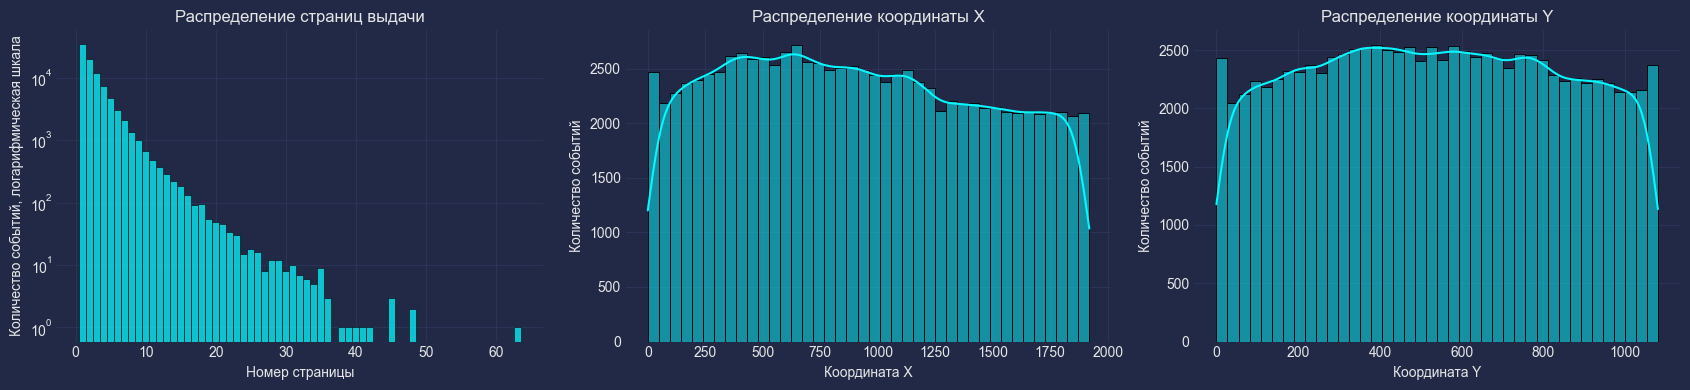

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

sns.histplot(
    data=events_clean,
    x="search_page",
    discrete=True,
    ax=axes[0],
)
axes[0].set_title("Распределение страниц выдачи")
axes[0].set_xlabel("Номер страницы")
axes[0].set_yscale("log")
axes[0].set_ylabel("Количество событий, логарифмическая шкала")

sns.histplot(
    data=events_clean,
    x="pointer_x",
    bins=40,
    ax=axes[1],
    kde=True
)
axes[1].set_title("Распределение координаты X")
axes[1].set_xlabel("Координата X")
axes[1].set_ylabel("Количество событий")

sns.histplot(
    data=events_clean,
    x="pointer_y",
    bins=40,
    ax=axes[2],
    kde=True
)
axes[2].set_title("Распределение координаты Y")
axes[2].set_xlabel("Координата Y")
axes[2].set_ylabel("Количество событий")

plt.tight_layout()
plt.show()

### Проверка времени создания куки

In [29]:
cookie_created = pd.concat(
    [
        train[["cookie_id", "cookie_created_at"]],
        test[["cookie_id", "cookie_created_at"]],
    ],
    ignore_index=True,
)

first_events = (
    events_clean.groupby("cookie_id")["event_ts"]
    .min()
    .rename("first_event_ts")
    .reset_index()
)

creation_check = first_events.merge(
    cookie_created,
    on="cookie_id",
    how="left",
)

creation_check["days_since_creation"] = (
    creation_check["first_event_ts"]
    - creation_check["cookie_created_at"]
).dt.total_seconds() / 86400

In [30]:
events_before_creation = creation_check.loc[
    creation_check["days_since_creation"] < 0
]

print(
    "Куки с событиями раньше времени создания:",
    len(events_before_creation),
)

display(events_before_creation.head())

Куки с событиями раньше времени создания: 0


,cookie_id,first_event_ts,cookie_created_at,days_since_creation


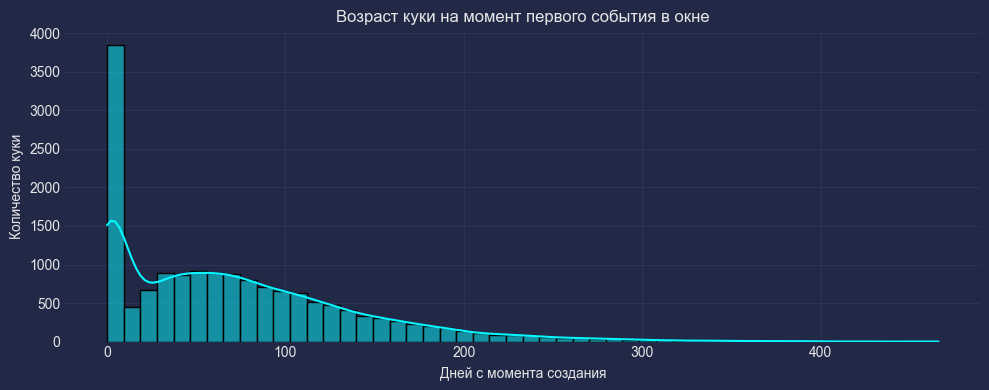

In [31]:
plt.figure(figsize=(10, 4))

sns.histplot(
    data=creation_check,
    x="days_since_creation",
    bins=50,
    kde=True
)

plt.title("Возраст куки на момент первого события в окне")
plt.xlabel("Дней с момента создания")
plt.ylabel("Количество куки")
plt.tight_layout()
plt.show()

### Количество событий на куку после очистки

In [32]:
cookie_meta = pd.concat(
    [
        train[["cookie_id"]].assign(dataset="train"),
        test[["cookie_id"]].assign(dataset="test"),
    ],
    ignore_index=True,
)

event_counts = (
    events_clean.groupby("cookie_id")
    .size()
    .rename("n_events")
    .reset_index()
)

cookie_activity = cookie_meta.merge(
    event_counts,
    on="cookie_id",
    how="left",
)

cookie_activity["n_events"] = (
    cookie_activity["n_events"]
    .fillna(0)
    .astype(int)
)

In [33]:
for name, group in cookie_activity.groupby("dataset"):
    print(
        f"{name}: куки без событий — "
        f"{group['n_events'].eq(0).sum()}"
    )

test: куки без событий — 0
train: куки без событий — 0


In [34]:
display(
    cookie_activity.groupby("dataset")["n_events"]
    .describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99])
    .round(2)
)

,count,mean,std,min,1%,10%,50%,90%,99%,max
dataset,,,,,,,,,,
test,4909.0,18.00,18.37,1.0,1.0,3.0,12.0,39.0,91.0,187.0
train,11091.0,17.63,17.44,1.0,1.0,3.0,12.0,39.0,86.0,165.0


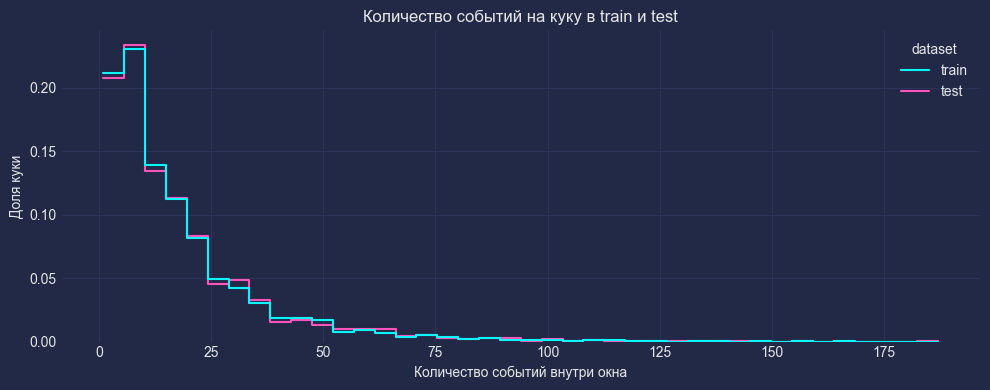

In [35]:
plt.figure(figsize=(10, 4))

sns.histplot(
    data=cookie_activity,
    x="n_events",
    hue="dataset",
    bins=40,
    stat="probability",
    common_norm=False,
    element="step",
    fill=False,
)

plt.title("Количество событий на куку в train и test")
plt.xlabel("Количество событий внутри окна")
plt.ylabel("Доля куки")
plt.tight_layout()
plt.show()

In [36]:
activity_groups = pd.cut(
    cookie_activity["n_events"],
    bins=[-1, 0, 1, 2, float("inf")],
    labels=["Нет событий", "1 событие", "2 события", "3 и более"],
)

activity_summary = (
    pd.crosstab(
        cookie_activity["dataset"],
        activity_groups,
        normalize="index",
    )
    .mul(100)
    .reindex(
        columns=["Нет событий", "1 событие", "2 события", "3 и более"],
        fill_value=0,
    )
)

display(activity_summary.round(2))

n_events,Нет событий,1 событие,2 события,3 и более
dataset,,,,
test,0,2.14,4.01,93.85
train,0,2.29,3.56,94.15


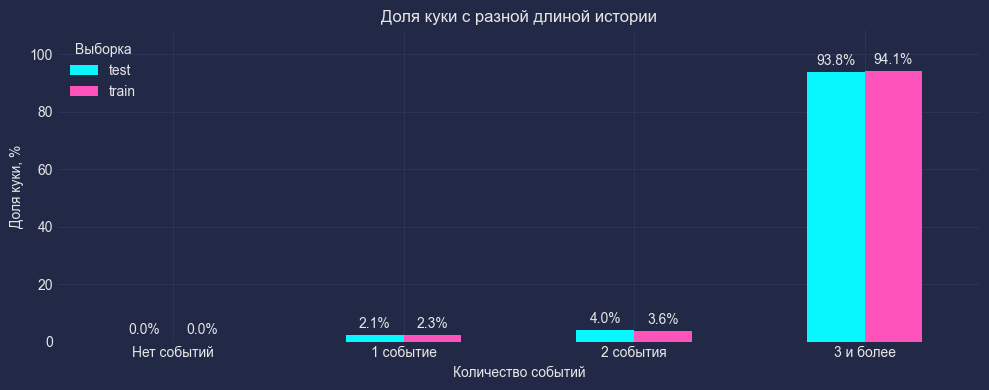

In [37]:
ax = activity_summary.T.plot(
    kind="bar",
    figsize=(10, 4),
    rot=0,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

ax.set_title("Доля куки с разной длиной истории")
ax.set_xlabel("Количество событий")
ax.set_ylabel("Доля куки, %")
ax.legend(title="Выборка")
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

### Вывод
- Удалены 4863 полных дубликата исходных событий и 40 209 событий за пределами окна. Для построения признаков осталось 283 833 события. У каждой куки есть хотя бы одно событие внутри окна.
- Пропуски зависят от типа события и платформы. Поэтому общей замены пропусков на нули не делал. Статистики считал по доступным значениям, а отсутствие наблюдений сохранял.

---

**Примечание** <br>
Ноль и пропуск различаем по смыслу. Отсутствие определённого события даёт нулевой счётчик. Если наблюдений недостаточно для расчёта статистики, оставляем NaN. Например, стандартное отклонение не определено по одному наблюдению.

Названия платформ приводим к общему виду, поисковые запросы — к нижнему регистру с нормализацией пробелов. Для категорий строим счётчики и доли, а в соответствующем блоке пропуск учитывается как отдельная категория.

## Построение признаков

### Базовые признаки

Для модели нужна одна строка на куку, поэтому события агрегировал внутри каждого окна наблюдения.

Использовал следующие группы признаков:

- Количество и доли действий — описывают состав активности: просмотры, поиск, контакты, избранное и другие события.
- Разнообразие объявлений, категорий, локаций и запросов — позволяет учитывать повторные действия и широту просмотра.
- Интервалы между событиями — описывают темп и регулярность действий.
- Распределение активности по часам — показывает, насколько события сосредоточены в коротком промежутке.
- Статистики координат — описывают наличие и разброс наблюдаемых позиций курсора. Полной траекторией движения мыши эти данные не являются.
- Статистики поиска — учитывают глубину выдачи и длины запросов.
- Доли User-Agent — описывают состав клиентов, с которых поступали события куки.

cookie_id используется для группировки и формирования ответа.
Идентификаторы объявлений используются только для расчёта агрегатов.

In [38]:
# Признаки считал отдельно для каждой куки, target в общую таблицу не добавлял
meta_columns = [
    "cookie_id",
    "cookie_created_at",
    "window_start_ts",
    "window_end_ts",
]

features = (
    pd.concat(
        [train[meta_columns], test[meta_columns]],
        ignore_index=True,
    )
    .set_index("cookie_id")
)

features.head()

,cookie_created_at,window_start_ts,window_end_ts
cookie_id,,,
ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07
ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07
ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07
ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07
ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07


In [39]:
features["n_events"] = (
    events_clean.groupby("cookie_id").size()
)

features["n_events"] = (
    features["n_events"].fillna(0).astype(int)
)

In [40]:
event_types = [
    "search_results_view",
    "item_view",
    "photo_swipe",
    "seller_page_view",
    "contact_phone_show",
    "contact_chat_open",
    "contact_message_sent",
    "favorite_add",
    "login",
]

event_type_counts = pd.crosstab(
    events_clean["cookie_id"],
    events_clean["event_name"],
)

event_type_counts = (
    event_type_counts
    .reindex(
        index=features.index,
        columns=event_types,
        fill_value=0,
    )
    .add_prefix("count_")
)

event_type_counts.columns.name = None

count_columns = event_type_counts.columns.tolist()

features[count_columns] = event_type_counts

display(features[count_columns].head())

,count_search_results_view,count_item_view,count_photo_swipe,count_seller_page_view,count_contact_phone_show,count_contact_chat_open,count_contact_message_sent,count_favorite_add,count_login
cookie_id,,,,,,,,,
ck_54a059eb7d3ea68b,3,3,1,0,0,0,0,0,0
ck_7e4de46eeab82974,8,22,4,4,1,0,0,1,1
ck_9320229ef6304522,13,7,3,3,2,1,1,3,3
ck_30ccd25bc1714ed9,3,14,0,2,1,1,0,0,0
ck_a77c5f05948cdeef,6,12,4,3,1,0,0,2,0


In [41]:
share_columns = [
    f"share_{event_type}"
    for event_type in event_types
]

event_type_shares = features[count_columns].div(
    features["n_events"].where(features["n_events"] > 0),
    axis=0,
)

event_type_shares.columns = share_columns

features[share_columns] = event_type_shares

display(features[share_columns].head())

,share_search_results_view,share_item_view,share_photo_swipe,share_seller_page_view,share_contact_phone_show,share_contact_chat_open,share_contact_message_sent,share_favorite_add,share_login
cookie_id,,,,,,,,,
ck_54a059eb7d3ea68b,0.428571,0.428571,0.142857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ck_7e4de46eeab82974,0.195122,0.536585,0.097561,0.097561,0.024390,0.000000,0.000000,0.024390,0.024390
ck_9320229ef6304522,0.361111,0.194444,0.083333,0.083333,0.055556,0.027778,0.027778,0.083333,0.083333
ck_30ccd25bc1714ed9,0.142857,0.666667,0.000000,0.095238,0.047619,0.047619,0.000000,0.000000,0.000000
ck_a77c5f05948cdeef,0.214286,0.428571,0.142857,0.107143,0.035714,0.000000,0.000000,0.071429,0.000000


In [42]:
item_views = events_clean.loc[
    events_clean["event_name"] == "item_view"
]

features["n_unique_items_viewed"] = (
    item_views.groupby("cookie_id")["item_id"]
    .nunique()
    .reindex(features.index, fill_value=0)
)

known_item_view_counts = (
    item_views.groupby("cookie_id")["item_id"]
    .count()
    .reindex(features.index, fill_value=0)
)

features["unique_item_view_ratio"] = (
    features["n_unique_items_viewed"]
    / known_item_view_counts.where(known_item_view_counts > 0)
)

In [43]:
# Возраст куки считал на момент окончания окна
features["cookie_age_days"] = (
    features["window_end_ts"]
    - features["cookie_created_at"]
).dt.total_seconds() / 86400

features["created_in_window"] = (
    (features["cookie_created_at"] >= features["window_start_ts"])
    & (features["cookie_created_at"] < features["window_end_ts"])
).astype(int)

In [44]:
basic_feature_columns = [
    "n_events",
    *count_columns,
    *share_columns,
    "n_unique_items_viewed",
    "unique_item_view_ratio",
    "cookie_age_days",
    "created_in_window",
]

print("Количество куки:", len(features))
print("Количество базовых признаков:", len(basic_feature_columns))

display(features[basic_feature_columns].head())

Количество куки: 16000
Количество базовых признаков: 23


,n_events,count_search_results_view,count_item_view,count_photo_swipe,count_seller_page_view,count_contact_phone_show,count_contact_chat_open,count_contact_message_sent,count_favorite_add,count_login,...,share_seller_page_view,share_contact_phone_show,share_contact_chat_open,share_contact_message_sent,share_favorite_add,share_login,n_unique_items_viewed,unique_item_view_ratio,cookie_age_days,created_in_window
cookie_id,,,,,,,,,,,,,,,,,,,,,
ck_54a059eb7d3ea68b,7,3,3,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3,1.000000,136.603692,0
ck_7e4de46eeab82974,41,8,22,4,4,1,0,0,1,1,...,0.097561,0.024390,0.000000,0.000000,0.024390,0.024390,14,0.636364,195.576111,0
ck_9320229ef6304522,36,13,7,3,3,2,1,1,3,3,...,0.083333,0.055556,0.027778,0.027778,0.083333,0.083333,6,0.857143,33.994421,0
ck_30ccd25bc1714ed9,21,3,14,0,2,1,1,0,0,0,...,0.095238,0.047619,0.047619,0.000000,0.000000,0.000000,9,0.642857,1.546759,0
ck_a77c5f05948cdeef,28,6,12,4,3,1,0,0,2,0,...,0.107143,0.035714,0.000000,0.000000,0.071429,0.000000,12,1.000000,95.837095,0


## Обучение моделей

### Добавление временных признаков

Проверка, помогает ли информация об интервалах и регулярности действий отличать ботов от людей. Разбиение данных и параметры моделей сохраняются.

In [45]:
# Первый интервал каждой куки остаётся пропуском
events_time = (
    events_clean[["cookie_id", "event_ts", "event_name"]]
    .sort_values(["cookie_id", "event_ts"])
    .copy()
)

events_time["gap_seconds"] = (
    events_time.groupby("cookie_id")["event_ts"]
    .diff()
    .dt.total_seconds()
)

display(events_time.head(10))

,cookie_id,event_ts,event_name,gap_seconds
0,ck_00013fdfa0bd37dd,2026-04-24 18:41:16,photo_swipe,NaN
1,ck_00013fdfa0bd37dd,2026-04-24 19:16:53,item_view,2137.0
2,ck_00013fdfa0bd37dd,2026-04-24 19:16:54,photo_swipe,1.0
3,ck_00013fdfa0bd37dd,2026-04-24 19:17:05,item_view,11.0
4,ck_00013fdfa0bd37dd,2026-04-24 20:05:05,login,2880.0
5,ck_00013fdfa0bd37dd,2026-04-24 20:31:33,item_view,1588.0
6,ck_00013fdfa0bd37dd,2026-04-24 20:34:06,search_results_view,153.0
7,ck_00013fdfa0bd37dd,2026-04-24 20:36:30,login,144.0
8,ck_00013fdfa0bd37dd,2026-04-24 20:36:32,contact_chat_open,2.0
9,ck_00013fdfa0bd37dd,2026-04-24 20:41:33,search_results_view,301.0


In [46]:
activity_times = (
    events_time.groupby("cookie_id")["event_ts"]
    .agg(["min", "max"])
)

time_features = pd.DataFrame(index=features.index)

time_features["activity_span_seconds"] = (
    activity_times["max"] - activity_times["min"]
).dt.total_seconds()

In [47]:
# Для std нужны хотя бы два интервала, при одном оставлял NaN
gap_stats = (
    events_time.groupby("cookie_id")["gap_seconds"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

gap_stats.columns = [
    "n_gaps",
    "gap_mean",
    "gap_median",
    "gap_std",
    "gap_min",
    "gap_max",
]

time_features[gap_stats.columns] = gap_stats

time_features["n_gaps"] = (time_features["n_gaps"].fillna(0).astype(int))

time_features["gap_cv"] = (time_features["gap_std"] / time_features["gap_mean"].where(time_features["gap_mean"] > 0))

In [48]:
valid_gaps = events_time.loc[
    events_time["gap_seconds"].notna(),
    ["cookie_id", "gap_seconds"],
].copy()

valid_gaps["gap_zero_share"] = valid_gaps["gap_seconds"].eq(0)
valid_gaps["gap_le_1s_share"] = valid_gaps["gap_seconds"].le(1)
valid_gaps["gap_le_5s_share"] = valid_gaps["gap_seconds"].le(5)
valid_gaps["gap_le_10s_share"] = valid_gaps["gap_seconds"].le(10)

gap_share_columns = [
    "gap_zero_share",
    "gap_le_1s_share",
    "gap_le_5s_share",
    "gap_le_10s_share",
]

gap_shares = (valid_gaps.groupby("cookie_id")[gap_share_columns].mean())

time_features[gap_share_columns] = gap_shares

In [49]:
item_times = events_time.loc[events_time["event_name"] == "item_view", ["cookie_id", "event_ts"],].copy()

item_times["gap_seconds"] = (
    item_times.groupby("cookie_id")["event_ts"]
    .diff()
    .dt.total_seconds()
)

item_gap_stats = (
    item_times.groupby("cookie_id")["gap_seconds"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

item_gap_stats.columns = [
    "n_item_gaps",
    "item_gap_mean",
    "item_gap_median",
    "item_gap_std",
    "item_gap_min",
    "item_gap_max",
]

time_features[item_gap_stats.columns] = item_gap_stats

time_features["n_item_gaps"] = (time_features["n_item_gaps"].fillna(0).astype(int))

time_features["item_gap_cv"] = (
    time_features["item_gap_std"]
    / time_features["item_gap_mean"].where(
        time_features["item_gap_mean"] > 0
    )
)

In [50]:
time_feature_columns = time_features.columns.tolist()

features[time_feature_columns] = time_features

extended_feature_columns = (basic_feature_columns + time_feature_columns)

print("Базовых признаков:", len(basic_feature_columns))
print("Временных признаков:", len(time_feature_columns))
print("Всего:", len(extended_feature_columns))

display(
    pd.DataFrame({
        "Пропуски": time_features.isna().sum(),
        "Доля пропусков, %": (
            time_features.isna().mean() * 100
        ).round(2),
    })
)

Базовых признаков: 23
Временных признаков: 19
Всего: 42


,Пропуски,"Доля пропусков, %"
activity_span_seconds,0,0.00
n_gaps,0,0.00
gap_mean,359,2.24
gap_median,359,2.24
gap_std,951,5.94
gap_min,359,2.24
gap_max,359,2.24
gap_cv,951,5.94
gap_zero_share,359,2.24
gap_le_1s_share,359,2.24


### Разнообразие просмотров и поисковое поведение

Проверка, помогает ли информация о разнообразии категорий, локаций и поисковых запросов, повторных просмотрах и глубине выдачи. Признаки рассчитывал внутри окна каждой куки. Для сравнения сохранил разбиение данных и параметры CatBoost.

In [51]:
item_events = events_clean.loc[
    events_clean["event_name"].eq("item_view")
].copy()

diversity_features = pd.DataFrame(index=features.index)

item_group = item_events.groupby("cookie_id")

for column, feature_name in {
    "item_category": "n_unique_categories",
    "item_location": "n_unique_locations",
    "seller_type": "n_unique_seller_types",
}.items():
    diversity_features[feature_name] = (
        item_group[column]
        .nunique()
        .reindex(features.index, fill_value=0)
    )

known_item_views = (
    item_group["item_id"]
    .count()
    .reindex(features.index, fill_value=0)
)

unique_item_views = (
    item_group["item_id"]
    .nunique()
    .reindex(features.index, fill_value=0)
)

diversity_features["n_repeat_item_views"] = (
    known_item_views - unique_item_views
)

display(diversity_features.head())

,n_unique_categories,n_unique_locations,n_unique_seller_types,n_repeat_item_views
cookie_id,,,,
ck_54a059eb7d3ea68b,2,3,2,0
ck_7e4de46eeab82974,1,8,2,8
ck_9320229ef6304522,4,2,2,1
ck_30ccd25bc1714ed9,1,4,2,5
ck_a77c5f05948cdeef,4,4,2,0


In [52]:
for column, feature_name in {
    "item_id": "top_item_share",
    "item_category": "top_category_share",
    "item_location": "top_location_share",
}.items():
    value_counts = (
        item_events
        .groupby(["cookie_id", column])
        .size()
    )

    top_count = value_counts.groupby(level=0).max()
    total_count = value_counts.groupby(level=0).sum()

    diversity_features[feature_name] = top_count / total_count

display(
    diversity_features[
        ["top_item_share", "top_category_share", "top_location_share"]
    ].describe()
)

,top_item_share,top_category_share,top_location_share
count,14964.000000,14840.000000,14903.000000
mean,0.396143,0.772403,0.596282
std,0.290788,0.231556,0.280016
min,0.026316,0.181818,0.090909
25%,0.176471,0.555556,0.333333
50%,0.333333,0.800000,0.500000
75%,0.500000,1.000000,0.857143
max,1.000000,1.000000,1.000000


In [53]:
search_events = events_clean.loc[
    events_clean["event_name"].eq("search_results_view")
].copy()

search_events["search_query"] = (
    search_events["search_query"].replace(r"^\s*$", np.nan, regex=True)
)

search_group = search_events.groupby("cookie_id")

diversity_features["n_unique_queries"] = (
    search_group["search_query"]
    .nunique()
    .reindex(features.index, fill_value=0)
)

known_query_count = (
    search_group["search_query"]
    .count()
    .reindex(features.index, fill_value=0)
)

diversity_features["unique_query_ratio"] = (
    diversity_features["n_unique_queries"]
    / known_query_count.where(known_query_count > 0)
)

query_counts = (
    search_events
    .groupby(["cookie_id", "search_query"])
    .size()
)

diversity_features["top_query_share"] = (
    query_counts.groupby(level=0).max()
    / query_counts.groupby(level=0).sum()
)

page_stats = search_group["search_page"].agg(
    ["max", "mean", "nunique"]
)

page_stats.columns = [
    "search_page_max",
    "search_page_mean",
    "n_unique_search_pages",
]

diversity_features[page_stats.columns] = page_stats

diversity_features["n_unique_search_pages"] = (diversity_features["n_unique_search_pages"].fillna(0).astype(int))

known_pages = search_events.loc[
    search_events["search_page"].notna(),
    ["cookie_id", "search_page"],
].copy()

known_pages["beyond_first_page"] = known_pages["search_page"].gt(1)

diversity_features["search_beyond_first_page_share"] = (known_pages.groupby("cookie_id")["beyond_first_page"].mean())

In [54]:
diversity_feature_columns = diversity_features.columns.to_list()

features[diversity_feature_columns] = diversity_features

behavior_feature_columns = (extended_feature_columns + diversity_feature_columns)

print("Базовые + время:", len(extended_feature_columns))
print("Новые признаки:", len(diversity_feature_columns))
print("Всего:", len(behavior_feature_columns))

display(
    pd.DataFrame({
        "Пропуски": diversity_features.isna().sum(),
        "Доля пропусков, %": (
            diversity_features.isna().mean() * 100
        ).round(2),
    })
)

Базовые + время: 42
Новые признаки: 14
Всего: 56


,Пропуски,"Доля пропусков, %"
n_unique_categories,0,0.00
n_unique_locations,0,0.00
n_unique_seller_types,0,0.00
n_repeat_item_views,0,0.00
top_item_share,1036,6.48
top_category_share,1160,7.25
top_location_share,1097,6.86
n_unique_queries,0,0.00
unique_query_ratio,1356,8.48
top_query_share,1356,8.48


In [55]:
timing_extra = pd.DataFrame(index=features.index)

# events_time уже отсортирован по cookie_id и event_ts
gap_group = events_time.groupby("cookie_id")["gap_seconds"]

gap_quantiles = (
    gap_group
    .quantile([0.10, 0.25, 0.75, 0.90])
    .unstack()
)

gap_quantiles.columns = [
    "gap_q10",
    "gap_q25",
    "gap_q75",
    "gap_q90",
]

timing_extra[gap_quantiles.columns] = gap_quantiles

timing_extra["gap_iqr"] = (timing_extra["gap_q75"] - timing_extra["gap_q25"])

observed_gaps = events_time.loc[events_time["gap_seconds"].notna(),["cookie_id", "gap_seconds"],].copy()

observed_gaps["gap_le30s_share"] = (observed_gaps["gap_seconds"].le(30))

observed_gaps["gap_gt5min_share"] = (observed_gaps["gap_seconds"].gt(300))

observed_gaps["gap_gt30min_share"] = (observed_gaps["gap_seconds"].gt(1800))

extra_gap_columns = [
    "gap_le30s_share",
    "gap_gt5min_share",
    "gap_gt30min_share",
]

timing_extra[extra_gap_columns] = (observed_gaps.groupby("cookie_id")[extra_gap_columns].mean())

In [56]:
event_bounds = (
    events_time.groupby("cookie_id")["event_ts"]
    .agg(["min", "max"])
    .reindex(features.index)
)

timing_extra["first_event_offset_seconds"] = (
    event_bounds["min"] - features["window_start_ts"]
).dt.total_seconds()

timing_extra["last_event_to_end_seconds"] = (
    features["window_end_ts"] - event_bounds["max"]
).dt.total_seconds()

### Расширение поведенческих признаков до 189

In [57]:
events_clean["pointer_x"] = pd.to_numeric(
    events_clean["pointer_x"],
    errors="coerce",
)

events_clean["pointer_y"] = pd.to_numeric(
    events_clean["pointer_y"],
    errors="coerce",
)

pointer_raw = (
    events_clean
    .groupby("cookie_id")[["pointer_x", "pointer_y"]]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "max",
        "nunique",
    ])
)

pointer_raw.columns = [
    f"rich_{column}_{stat}"
    for column, stat in pointer_raw.columns
]

pointer_raw = pointer_raw.reindex(features.index)

In [58]:
# Статистики считал по известным координатам
pointer_present = (events_clean["pointer_x"].notna() & events_clean["pointer_y"].notna())

pointer_present_count = (
    pointer_present
    .groupby(events_clean["cookie_id"])
    .sum()
    .reindex(features.index, fill_value=0)
)

pointer_raw["rich_pointer_present_count"] = (pointer_present_count)

pointer_raw["rich_pointer_ratio"] = (
    pointer_present_count
    / features["n_events"].where(
        features["n_events"] > 0
    )
)

pointer_raw_columns = pointer_raw.columns.tolist()

features = pd.concat(
    [
        features.drop(
            columns=pointer_raw_columns,
            errors="ignore",
        ),
        pointer_raw,
    ],
    axis=1,
).copy()

print("Добавлено признаков курсора:", len(pointer_raw_columns))

display(pointer_raw.head())

Добавлено признаков курсора: 14


,rich_pointer_x_count,rich_pointer_x_mean,rich_pointer_x_std,rich_pointer_x_min,rich_pointer_x_max,rich_pointer_x_nunique,rich_pointer_y_count,rich_pointer_y_mean,rich_pointer_y_std,rich_pointer_y_min,rich_pointer_y_max,rich_pointer_y_nunique,rich_pointer_present_count,rich_pointer_ratio
cookie_id,,,,,,,,,,,,,,
ck_54a059eb7d3ea68b,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,0,0,0.000000
ck_7e4de46eeab82974,38,917.868421,509.231969,2.0,1907.0,36,38,567.605263,272.953569,104.0,1053.0,38,38,0.926829
ck_9320229ef6304522,35,936.457143,602.124295,35.0,1904.0,35,35,556.657143,312.027426,22.0,1057.0,35,35,0.972222
ck_30ccd25bc1714ed9,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,0,0,0.000000
ck_a77c5f05948cdeef,27,978.000000,450.561957,30.0,1791.0,27,27,639.740741,295.966031,5.0,1041.0,27,27,0.964286


In [59]:
def safe_feature_token(value):
    value = str(value).lower().strip()
    value = re.sub(r"[^0-9a-zа-я]+", "_", value)
    return value.strip("_") or "empty"


distribution_parts = []

# Пропуск учитывал как категорию, доли считал от всех событий куки
for column in [
    "platform",
    "item_category",
    "seller_type",
]:
    values_data = events_clean[
        ["cookie_id", column]
    ].copy()

    values_data[column] = (
        values_data[column]
        .fillna("__missing__")
        .astype(str)
    )

    counts = pd.crosstab(
        values_data["cookie_id"],
        values_data[column],
    )

    raw_values = counts.columns.tolist()

    counts = counts.reindex(
        index=features.index,
        fill_value=0,
    )

    counts.columns = [
        f"rich_{column}_count__"
        f"{safe_feature_token(value)}"
        for value in raw_values
    ]

    ratios = counts.div(
        features["n_events"].where(
            features["n_events"] > 0
        ),
        axis=0,
    )

    ratios.columns = [
        column.replace(
            "_count__",
            "_ratio__",
        )
        for column in counts.columns
    ]

    distribution_parts.extend(
        [
            counts,
            ratios,
        ]
    )

rich_distribution_features = pd.concat(
    distribution_parts,
    axis=1,
)

rich_distribution_features.shape

(16000, 44)

In [60]:
rich_distribution_columns = (
    rich_distribution_features.columns.tolist()
)

features = pd.concat(
    [
        features.drop(
            columns=rich_distribution_columns,
            errors="ignore",
        ),
        rich_distribution_features,
    ],
    axis=1,
).copy()

print("Признаков counts/ratios:", len(rich_distribution_columns))

Признаков counts/ratios: 44


In [61]:
rich_global_features = (
    events_clean
    .groupby("cookie_id")
    .agg(
        rich_n_event_types=(
            "event_name",
            "nunique",
        ),
        rich_n_platforms=(
            "platform",
            "nunique",
        ),
        rich_n_categories=(
            "item_category",
            "nunique",
        ),
        rich_n_locations=(
            "item_location",
            "nunique",
        ),
        rich_n_seller_types=(
            "seller_type",
            "nunique",
        ),
        rich_n_items=(
            "item_id",
            "nunique",
        ),
        rich_n_queries=(
            "search_query",
            "nunique",
        ),
        rich_n_user_agents=(
            "user_agent",
            "nunique",
        ),
    )
    .reindex(features.index)
)

rich_global_features["rich_events_per_item"] = (
    features["n_events"]
    / rich_global_features["rich_n_items"]
        .replace(0, np.nan)
)

rich_global_features["rich_events_per_query"] = (
    features["n_events"]
    / rich_global_features["rich_n_queries"]
        .replace(0, np.nan)
)

rich_global_columns = (
    rich_global_features.columns.tolist()
)

features = pd.concat(
    [
        features.drop(
            columns=rich_global_columns,
            errors="ignore",
        ),
        rich_global_features,
    ],
    axis=1,
).copy()

In [62]:
query_events = events_clean.loc[
    events_clean["event_name"].eq("search_results_view")
    & events_clean["search_query"].notna()
    & events_clean["search_query"].ne(""),
    ["cookie_id", "search_query"],
].copy()

query_events["query_length"] = (
    query_events["search_query"].str.len()
)

rich_query_features = (
    query_events.groupby("cookie_id")["query_length"]
    .agg(["mean", "median", "std", "max"])
    .rename(columns=lambda stat: f"rich_query_length_{stat}")
    .reindex(features.index)
)

In [63]:
rich_query_columns = rich_query_features.columns.to_list()

features = pd.concat(
    [
        features.drop(columns=rich_query_columns, errors="ignore"),
        rich_query_features,
    ],
    axis=1,
).copy()

In [64]:
# Часы отсчитываем от начала окна каждой куки
hour_events = events_clean[["cookie_id", "event_ts"]].copy()

hour_events["window_start_ts"] = (
    hour_events["cookie_id"].map(features["window_start_ts"])
)

hour_events["window_hour"] = (
    (hour_events["event_ts"] - hour_events["window_start_ts"])
    .dt.total_seconds()
    .floordiv(3600)
    .astype(int)
)

hour_counts = pd.crosstab(
    hour_events["cookie_id"],
    hour_events["window_hour"],
).reindex(
    index=features.index,
    columns=range(24),
    fill_value=0,
)

In [65]:
hour_totals = hour_counts.sum(axis=1)

hour_shares = hour_counts.div(
    hour_totals.where(hour_totals > 0),
    axis=0,
)

hour_share_columns = [
    f"window_hour_{hour:02d}_share"
    for hour in range(24)
]

timing_extra[hour_share_columns] = hour_shares.rename(
    columns=dict(zip(range(24), hour_share_columns))
)

timing_extra["n_active_hours"] = hour_counts.gt(0).sum(axis=1)
timing_extra["hour_max_share"] = hour_shares.max(axis=1)

# Нулевые доли не дают вклада в энтропию
entropy_terms = (
    hour_shares * np.log(hour_shares.where(hour_shares > 0))
)

timing_extra["hour_entropy"] = (
    -entropy_terms.sum(axis=1) / np.log(24)
).where(hour_totals > 0)

In [66]:
timing_extra_columns = timing_extra.columns.to_list()

features = pd.concat(
    [
        features.drop(columns=timing_extra_columns, errors="ignore"),
        timing_extra,
    ],
    axis=1,
).copy()

rich_time_columns = (
    behavior_feature_columns + timing_extra_columns
)

print("Расширенных временных признаков:", len(timing_extra_columns))
print("Поведенческих и временных признаков:", len(rich_time_columns))

Расширенных временных признаков: 37
Поведенческих и временных признаков: 93


In [67]:
rich_hour_counts = hour_counts.copy()

rich_hour_counts.columns = [
    f"rich_window_hour_count__{hour:02d}"
    for hour in rich_hour_counts.columns
]

rich_hour_count_columns = (
    rich_hour_counts.columns.tolist()
)

features = pd.concat(
    [
        features.drop(
            columns=rich_hour_count_columns,
            errors="ignore",
        ),
        rich_hour_counts,
    ],
    axis=1,
).copy()

In [68]:
rich_feature_columns = list(
    dict.fromkeys(
        rich_time_columns
        + pointer_raw_columns
        + rich_distribution_columns
        + rich_global_columns
        + rich_query_columns
        + rich_hour_count_columns
    )
)

print(
    "Признаков в новом наборе:",
    len(rich_feature_columns),
)

print(
    "Старый набор:",
    len(rich_time_columns),
)

Признаков в новом наборе: 189
Старый набор: 93


In [69]:
lgbm_rich_params = {
    "n_estimators": 700,
    "learning_rate": 0.035,
    "num_leaves": 31,
    "min_child_samples": 30,
    "colsample_bytree": 0.85,
    "reg_lambda": 1.0,
    "random_state": RANDOM_STATE,
    "n_jobs": 4,
    "verbosity": -1,
    "deterministic": True,
    "force_col_wise": True,
}

### Доли конкретных User-Agent

Ранее проверял обобщённые признаки браузера и операционной системы. Теперь для каждой куки считаю доли событий с конкретными User-Agent, т.е. другое представление UA. Оно может различать известные клиенты, но сильнее зависит от их состава и версий.

In [70]:
ua_source = (
    events_clean["user_agent"]
    .astype("string")
    .fillna("__MISSING__")
)

ua_counts = pd.crosstab(
    events_clean["cookie_id"],
    ua_source,
)

ua_feature_columns = [
    f"ua_ratio__{i}"
    for i in range(ua_counts.shape[1])
]

ua_counts.columns = ua_feature_columns

ua_ratios = (
    ua_counts
    .div(
        features["n_events"].replace(0, np.nan),
        axis=0,
    )
    .fillna(0)
)

features = features.drop(
    columns=ua_feature_columns,
    errors="ignore",
)

features = features.join(
    ua_ratios,
    how="left",
)

features[ua_feature_columns] = (
    features[ua_feature_columns]
    .fillna(0)
)

print("Количество UA-признаков:", len(ua_feature_columns))

Количество UA-признаков: 148


In [71]:
rich_ua_feature_columns = list(
    dict.fromkeys(
        rich_feature_columns
        + ua_feature_columns
    )
)

rich_ua_data = train.merge(
    features[rich_ua_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

# Нули нужны только для UA-долей: отсутствие конкретного User-Agent означает долю 0
rich_ua_data[ua_feature_columns] = (
    rich_ua_data[ua_feature_columns]
    .fillna(0)
)

print("Количество признаков:", len(rich_ua_feature_columns),)

print(
    "Пропуски в rich-признаках:",
    rich_ua_data[rich_feature_columns]
    .isna()
    .sum()
    .sum(),
)

Количество признаков: 337
Пропуски в rich-признаках: 90886


### Взвешенный LightGBM и ансамбль на трёх временных разбиениях

## Валидация

Тестовые окна расположены позже обучающих, поэтому использую
временное разбиение, на каждом следующем периоде обучающая
выборка расширяется.

| Обучение | Валидация |
|---|---|
| 6–9 апреля | 10–12 апреля |
| 6–12 апреля | 13–16 апреля |
| 6–16 апреля | 17–19 апреля |

В обучение включал только куки, окна которых завершились к началу соответствующего периода валидации.

Основную метрику брал из metric.py. Ранняя остановка выполняется по binary logloss. Для сравнения вариантов использовал P@R≥0.7 на каждом периоде, а также среднее и минимальное значение по периодам.

In [72]:
ua_temporal_folds = [
    {
        "name": "10–12 апреля",
        "valid_start": pd.Timestamp("2026-04-10"),
        "valid_end": pd.Timestamp("2026-04-13"),
    },
    {
        "name": "13–16 апреля",
        "valid_start": pd.Timestamp("2026-04-13"),
        "valid_end": pd.Timestamp("2026-04-17"),
    },
    {
        "name": "17–19 апреля",
        "valid_start": pd.Timestamp("2026-04-17"),
        "valid_end": pd.Timestamp("2026-04-20"),
    },
]

In [73]:
ua_params_1 = lgbm_rich_params.copy()
ua_params_1.update({
    "scale_pos_weight": 3.0,
    "colsample_bytree": 0.85,
    "min_child_samples": 30,
})

ua_params_2 = ua_params_1.copy()
ua_params_2["colsample_bytree"] = 0.70

ua_params_3 = ua_params_1.copy()
ua_params_3["min_child_samples"] = 15

ua_param_sets = {
    "spw3_c85_leaf30": ua_params_1,
    "spw3_c70_leaf30": ua_params_2,
    "spw3_c85_leaf15": ua_params_3,
}

In [74]:
def fit_temporal_lgbm(
    data,
    feature_columns,
    folds,
    params,
):
    predictions = {}
    score_rows = []
    best_iterations = {}

    for fold in folds:
        fold_name = fold["name"]

        # К началу валидации обучающие окна должны быть завершены
        train_mask = (
            (data["window_start_ts"] < fold["valid_start"])
            & (data["window_end_ts"] <= fold["valid_start"])
        )

        valid_mask = (
            (data["window_start_ts"] >= fold["valid_start"])
            & (data["window_start_ts"] < fold["valid_end"])
        )

        model = LGBMClassifier(**params)

        # Раннюю остановку делаем по logloss, варианты сравниваем по P@R≥0.7
        model.fit(
            data.loc[train_mask, feature_columns],
            data.loc[train_mask, "target"],
            eval_set=[
                (
                    data.loc[valid_mask, feature_columns],
                    data.loc[valid_mask, "target"],
                )
            ],
            eval_metric="binary_logloss",
            callbacks=[
                lgb.early_stopping(60, verbose=False),
            ],
        )

        fold_prediction = model.predict_proba(
            data.loc[valid_mask, feature_columns],
            num_iteration=model.best_iteration_,
        )[:, 1]

        predictions[fold_name] = fold_prediction

        score_rows.append({
            "fold": fold_name,
            "p_at_recall_70": precision_at_recall(
                data.loc[valid_mask, "target"],
                fold_prediction,
            ),
            "best_iteration": model.best_iteration_,
        })

        best_iterations[fold_name] = model.best_iteration_

    return (
        predictions,
        pd.DataFrame(score_rows),
        best_iterations,
    )

In [75]:
ua_predictions = {}
ua_score_tables = []
ua_best_iterations = {}

for model_name, params in ua_param_sets.items():
    predictions, scores, best_iterations = fit_temporal_lgbm(
        rich_ua_data,
        rich_ua_feature_columns,
        ua_temporal_folds,
        params,
    )

    ua_predictions[model_name] = predictions
    ua_best_iterations[model_name] = best_iterations

    scores["model"] = model_name
    ua_score_tables.append(scores)

ua_scores = pd.concat(
    ua_score_tables,
    ignore_index=True,
)

In [76]:
ua_summary = (
    ua_scores
    .groupby("model")["p_at_recall_70"]
    .agg(
        mean="mean",
        minimum="min",
    )
    .sort_values("mean", ascending=False)
)

display(ua_summary)

,mean,minimum
model,,
spw3_c85_leaf15,0.759207,0.725000
spw3_c70_leaf30,0.745925,0.728033
spw3_c85_leaf30,0.739350,0.696000


In [77]:
ua_ensemble_predictions = {}
ua_ensemble_rows = []

model_names = list(ua_param_sets)

for fold in ua_temporal_folds:
    fold_name = fold["name"]

    valid_mask = (
        (rich_ua_data["window_start_ts"] >= fold["valid_start"])
        & (rich_ua_data["window_start_ts"] < fold["valid_end"])
    )

    y_valid = rich_ua_data.loc[
        valid_mask,
        "target",
    ].to_numpy()

    fold_prediction = np.mean(
        [
            ua_predictions[model_name][fold_name]
            for model_name in model_names
        ],
        axis=0,
    )

    ua_ensemble_predictions[fold_name] = fold_prediction

    ua_ensemble_rows.append({
        "fold": fold_name,
        "p_at_recall_70": precision_at_recall(
            y_valid,
            fold_prediction,
        ),
    })

ua_ensemble_scores = pd.DataFrame(
    ua_ensemble_rows,
)

display(ua_ensemble_scores)

,fold,p_at_recall_70
0,10–12 апреля,0.761905
1,13–16 апреля,0.737288
2,17–19 апреля,0.800000


In [78]:
print(
    "Средний P@R≥0.7:",
    ua_ensemble_scores["p_at_recall_70"].mean(),
)

print(
    "Минимальный P@R≥0.7:",
    ua_ensemble_scores["p_at_recall_70"].min(),
)

Средний P@R≥0.7: 0.7663976324993275
Минимальный P@R≥0.7: 0.7372881355932204


## Обучение на всей выборке

Для каждой конфигурации брал медиану лучших итераций по трём временным разбиениям, с этим числом деревьев обучал модели на всём train.

In [79]:
ua_final_iterations = {}

# Для полного обучения брал медиану лучших итераций по временным разбиениям
for model_name, fold_iterations in ua_best_iterations.items():
    ua_final_iterations[model_name] = int(
        np.median(
            list(fold_iterations.values())
        )
    )

display(
    pd.Series(
        ua_final_iterations,
        name="n_estimators",
    )
)

spw3_c85_leaf30    168
spw3_c70_leaf30    183
spw3_c85_leaf15    187
Name: n_estimators, dtype: int64

In [80]:
test_ua_data = test.merge(
    features[rich_ua_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

# Заполнял только UA-признаки, пропуски в rich-признаках сохранял
test_ua_data[ua_feature_columns] = (
    test_ua_data[ua_feature_columns]
    .fillna(0)
)

X_full_ua = rich_ua_data[
    rich_ua_feature_columns
]

y_full_ua = rich_ua_data["target"]

X_test_ua = test_ua_data[
    rich_ua_feature_columns
]

In [81]:
final_ua_models = {}
final_ua_test_predictions = {}

for model_name, params in ua_param_sets.items():
    full_fit_params = params.copy()
    full_fit_params["n_estimators"] = ua_final_iterations[model_name]
    
    model = LGBMClassifier(**full_fit_params)

    model.fit(
        X_full_ua,
        y_full_ua,
    )

    final_ua_models[model_name] = model

    final_ua_test_predictions[model_name] = (
        model.predict_proba(X_test_ua)[:, 1]
    )

In [82]:
test_score = np.mean(
    list(final_ua_test_predictions.values()),
    axis=0,
)

test_score = np.clip(
    test_score,
    0,
    1,
)

submission = pd.DataFrame({
    "cookie_id": test["cookie_id"],
    "score": test_score,
})

submission.to_csv(
    "submission.csv",
    index=False,
)

submission.head()

,cookie_id,score
0,ck_315fb710a0e371e7,0.002912
1,ck_a76ee3b3e3e522fd,0.266138
2,ck_94c9a4d382689e82,0.124187
3,ck_8eaf9509ad9462a0,0.002253
4,ck_9a88a5a989cb5bc6,0.022633


In [83]:
print("Колонки:", submission.columns.tolist())
print("Размер:", submission.shape)
print("Дубликаты cookie_id:", submission["cookie_id"].duplicated().sum())
print("Пропуски score:", submission["score"].isna().sum())
print("Диапазон score:", submission["score"].min(), submission["score"].max())

Колонки: ['cookie_id', 'score']
Размер: (4909, 2)
Дубликаты cookie_id: 0
Пропуски score: 0
Диапазон score: 0.001212983576653103 0.9946349402021184


## Результаты и ограничения

Итоговый ансамбль получил следующие значения P@R≥0.7:

| Период валидации | P@R≥0.7 |
|---|---:|
| 10–12 апреля | 0.7619 |
| 13–16 апреля | 0.7373 |
| 17–19 апреля | 0.8000 |

Среднее по трём периодам = 0.7664, минимальное значение = 0.7373.

Все три периода использовались при выборе решения. Поэтому эти результаты характеризуют локальную валидацию и не являются независимой оценкой качества на новых данных.

Основные ограничения:
- Положительный класс состоит из известных сервисов сбора данных. Качество на других типах ботов отдельно не проверял.
- Доли конкретных User-Agent зависят от состава клиентов и их версий.
- Координаты курсора зависят не только от поведения, но и от платформы и особенностей интерфейса.
- У куки с короткой историей меньше информации для расчёта временных и других статистических признаков.